In [20]:
import random
import numpy as np
from math import log, sqrt
import bamnostic
import seqlogo as sl

In [21]:
BASES = ("A", "C", "G", "T")
BASE_INDEX = {"A": 0, "C": 1, "G": 2, "T": 3}

## Helper Functions
  `reverse_complement`, `build_pfm`, `build_pwm` `score_kmer` were provided helper functions slightly modified to include edge cases. 

In [22]:
COMP_TRANS = str.maketrans('ACGTacgt', 'TGCAtcga')
def reverse_complement(seq):
    # from seq_ops
    """Get the reverse complement of a nucleotide sequence

    Returns the reverse complement of the input string representing a DNA
    sequence. Works only with DNA sequences consisting solely of  A, C, G, T or N
    characters. Preserves the case of the input sequence.

    Args:
        seq (str): a DNA sequence string

    Returns:
        (str): The reverse complement of the input DNA sequence string.
    """

    # Translate then reverse seq
    return seq.translate(COMP_TRANS)[::-1]


In [23]:
def get_reads_from_bam(bam_path, n, seed=None):
    rng = random.Random(seed)
    bam = bamnostic.AlignmentFile(bam_path, "rb")

    reservoir = []
    seen = 0  # number of reads seen so far

    for read in bam:
        if getattr(read, "is_unmapped", True) or getattr(read, "is_secondary", True) or \
           getattr(read, "is_supplementary", True):
            continue
        seq = getattr(read, "query_sequence", None)
        if getattr(read, "is_reverse", False):
            seq = reverse_complement(seq)
        seen += 1
        if len(reservoir) < n:
            reservoir.append(seq)
        else:
            j = rng.randrange(seen)
            if j < n:
                reservoir[j] = seq

    bam.close()

    print(f"successfully retrieved {len(reservoir)} reads from bam file.")
    return reservoir

In [24]:
def add_kmer_to_pfm(pfm: np.ndarray, kmer: str, sign: int) -> None:
    """
    in-place add (sign=+1) or remove (sign=-1) a k-mer from PFM.
    """
    for j, ch in enumerate(kmer):
        pfm[BASE_INDEX[ch], j] += sign

In [25]:
def frobenius_norm(mat: np.ndarray) -> float:
    return sqrt(float(np.sum(mat * mat)))

In [26]:
def is_valid_kmer(seq): # boolean helper
    return all(ch in BASE_INDEX for ch in seq)

In [27]:
def build_markov_0th_order(reads: list, pseudocount: float) -> dict:
    '''
    input: list of reads and background pseudocount
    returns a dict like {"A":pA,"C":pC,"G":pG,"T":pT}
    '''

    if pseudocount <= 0:
        raise ValueError("pseudocount must be > 0")

    a = c = g = t = 0

    for read in reads:
        if not read:
            continue
        r = read.upper()

        a += r.count("A")
        c += r.count("C")
        g += r.count("G")
        t += r.count("T")

    total = (a + c + g + t) + pseudocount * 4

    return {
        "A": (a + pseudocount) / total,
        "C": (c + pseudocount) / total,
        "G": (g + pseudocount) / total,
        "T": (t + pseudocount) / total,
    }

In [28]:
def build_pfm(sequences, length) -> np.ndarray:
    # like build_pfm from motif_ops but doesn't silently turn invalid characters into As
    pfm = np.zeros((4, length), dtype=np.int32)

    # one slot for every possible byte value, all initially -1
    base_to_index = np.full(256, -1, dtype=np.int16)
    base_to_index[ord('A')] = 0
    base_to_index[ord('C')] = 1
    base_to_index[ord('G')] = 2
    base_to_index[ord('T')] = 3

    cols = np.arange(length)

    for seq in sequences:
        seq_array = np.frombuffer(seq[:length].encode(), dtype=np.uint8)
        indices = base_to_index[seq_array]

        # only count valid A/C/G/T
        mask = indices >= 0
        np.add.at(pfm, (indices[mask], cols[mask]), 1)

    return pfm

In [29]:
def build_pwm(pfm, bg, pseudocount) -> np.ndarray:
    """
    PWM[b,j] = log2( P_motif(b|j) / P_bg(b) )
    pfm: (4, k) counts
    bg: dict like {"A":pA,"C":pC,"G":pG,"T":pT}
    """

    # like build_pwm from motif_ops but the background probs arent hardcoded
    # this format also only works for 0th order background models

    # bg (4, 1), it's a column vector in A,C,G,T order
    bg_vec = np.array([bg[b] for b in BASES], dtype=float).reshape(4, 1)

    # column sums (1, k)
    sums = pfm.sum(axis=0, keepdims=True) + 4 * pseudocount

    # motif probabilities (4, k)
    p_motif = (pfm.astype(float) + pseudocount) / sums

    # log-odds vs background
    pwm = np.log2(p_motif) - np.log2(bg_vec)

    return pwm

In [30]:
TRANS_TAB = str.maketrans('ACGT', '0123')
def score_kmer(seq: str, pwm: np.ndarray) -> float:
    # this is as it is in motif_ops
    """
    Score a k-mer using a Position Weight Matrix (PWM).

    The k-mer length is expected to be the same as the PWM length.

    Args:
        seq (str): k-mer to score.
        pwm (np.ndarray): PWM for scoring.

    Returns:
        float: PWM score for the k-mer.

    Raises:
        ValueError: If the k-mer and PWM are different lengths.
    """
    if len(seq) != len(pwm[0]):
        raise ValueError('K-mer and PWM are different lengths!')

    indices = np.fromiter((int(nt) for nt in seq.translate(TRANS_TAB)), dtype = int)
    return np.sum(pwm[indices, np.arange(len(indices))])

In [31]:
def pfm_ic(pfm: np.ndarray, p) -> float:
    #like pfm_ic in motif_ops, but motif pseudocount is parameterized
    sums = np.sum(pfm, axis=0) + 4 * p
    fij = (pfm + p) / sums
    ic = np.sum(2 + np.sum(fij * np.log2(fij), axis=0, where=fij > 0))
    return ic

In [32]:
def init_sites_and_matrices(reads, k, bg, seed, max_tries, pseudocount) -> \
    (list[int], list[str], np.ndarray, np.ndarray):
    """
    initiation:
    - choose random start positions for each read
    - build initial PFM/PWM from chosen k-mers

    input: reads, k, bg, seed, max tries (for choosing initial motif windows), motif pseudocount
    output: starts, candidates, pfm (integers), pwm (floats)
    """
    rng = random.Random(seed)

    starts = []
    candidates = []

    for read in reads:
        read=read.upper()
        L = len(read)
        if L < k:
            raise ValueError("all reads must have length >= k")

        for _ in range(max_tries):
            start = rng.randrange(0, L - k + 1)
            kmer = read[start:start + k]
            if is_valid_kmer(kmer):
                starts.append(start)
                candidates.append(kmer)
                break
        else:
            raise ValueError("could not sample a valid initial k-mer from read")


    pfm = build_pfm(candidates, k)
    pwm = build_pwm(pfm, bg, pseudocount=pseudocount)

    return starts, candidates, pfm, pwm

In [37]:
LN2 = log(2.0)
def gibbs_update(
    reads: list[str], starts: list[int], pfm: np.ndarray,
    i: int, k: int, bg: dict,
    motif_pseudocount: float,
    rng: random.Random,
    max_tries: int = 50 ) -> int:
    '''
    performs one gibbs move updating read i.

    effects are:
        changes start[i].
        changes pfm.

    returns the newly sampled start index for the read.
    '''

    read = reads[i].upper() # identify the read
    L = len(read)

    if L < k:
        raise ValueError("Read length < k")

    # identify current start position
    old_start = starts[i]

    # identify current candidate motif
    old_kmer = read[old_start:old_start + k]

    # uncount kmer in pfm
    add_kmer_to_pfm(pfm, old_kmer, sign=-1)

    # leave-one-out PWM
    loo_pwm = build_pwm(pfm, bg, pseudocount=motif_pseudocount)

    # number of starts to score
    n_starts = L - k + 1

    # initialize scores array and validity mask
    scores = np.zeros(n_starts, dtype=float)
    valid = np.zeros(n_starts, dtype=bool)

    # score each start to create a probability distribution
    for start in range(n_starts):

        kmer = read[start:start + k]

        if is_valid_kmer(kmer):
            valid[start] = True
            scores[start] = score_kmer(kmer, loo_pwm)
            # scores = log2(P(kmer|motif)/P(kmer|bg))
        else:
            continue

    valid_windows = np.flatnonzero(valid)
    if valid_windows.size == 0:
        # no valid windows; restore old k-mer if we removed it and keep start unchanged
        # defensive programming. init already found a valid window
        if is_valid_kmer(old_kmer):
            add_kmer_to_pfm(pfm, old_kmer, sign=+1) # put everything back
        return old_start

    #convert to weights
    m = float(np.max(scores[valid_windows])) # max score found
    w = np.zeros_like(scores) # initialize scores vector; the invalid windows will keep weight 0

    w[valid] = np.exp((scores[valid] - m) * LN2) # 2^x=(e^(ln2))^x=e^(xln2)
    # with x = score - max score, we keep weights between 0 and 1
    # the max scoring window has weight 2^x = 2^0 = 1, for everything else x is negative so 2^x is between 0 and 1
    # ie. cannot overflow and also makes debugging easier if it comes up

    # random choice
    # choices() wants lists
    population = valid_windows.tolist()
    w_list = w[valid].tolist()

    # choose new start probabilisitically
    new_start = rng.choices(population, weights=w_list, k=1)[0]

    # count new motif candidate in pfm
    new_kmer = read[new_start:new_start + k]
    add_kmer_to_pfm(pfm, new_kmer, sign=+1)
    starts[i] = new_start

    # print(f"""
    # read n. {i}:
    # start position {old_start} -> {new_start}
    # """)

    return new_start

## Main Wrapper Function

In [34]:
def GibbsMotifSampler(
    seqs: list[str], k: int, seed: int = 123,
    bg_pseudocount: float = 1.0, motif_pseudocount: float = 0.25,
    max_tries_init: int = 50,
    burn_in_sweeps: int = 1,
    check_every_sweeps: int = 10,
    rel_thresh: float = 0.001,
    max_sweeps: int = 100
    ) -> np.ndarray:

    if k <= 0:
        raise ValueError("k must be > 0")
    if not seqs:
        raise ValueError("seqs must be non-empty")

    # 0th order iid
    bg = build_markov_0th_order(seqs, bg_pseudocount)

    ###### INITIATION ##########
    rng = random.Random(seed)
    starts, candidates, pfm, pwm = \
        init_sites_and_matrices(
            seqs, k, bg, seed=seed, max_tries=max_tries_init, pseudocount=motif_pseudocount
            )

    print("burning in...")
    prev_pwm = None
    n = len(seqs)
    ######### ITERATION ###########
    for sweep in range(1, max_sweeps + 1):
        # one sweep = n single updates

        for _ in range(n):
            i = rng.randrange(0, len(seqs))
            gibbs_update(seqs, starts, pfm, i, k, bg, motif_pseudocount, rng)

        if sweep <= burn_in_sweeps: # are we still in burn-in
            continue
        if sweep == (burn_in_sweeps+1):
            print("..done burning in...")
        if (sweep - burn_in_sweeps) % check_every_sweeps != 0: # is it not checking time
            continue

        #### CHECK CONVERGENCE #####
        pwm_now = build_pwm(pfm, bg, pseudocount=motif_pseudocount)

        if prev_pwm is None:
            prev_pwm = pwm_now
            continue

        diff = pwm_now - prev_pwm

        num = frobenius_norm(diff)
        den = frobenius_norm(prev_pwm)
        rel = num / den if den > 0 else float("inf")

        prev_pwm = pwm_now
        ic = pfm_ic(pfm,motif_pseudocount)
        print(f"""
        {sweep} sweeps complete,
        IC = {ic:3f},
        relative Frobenius diff = {rel:3f}
        """)

        if rel < rel_thresh:
            break

    return pfm

## Driver Program
Note: Changes were made to include parameters not included in the original example.

In [40]:
seed=123

seqs = get_reads_from_bam("data/SRR9090854.subsampled_5pct.bam",10000,seed=seed)

pfm = GibbsMotifSampler(
    seqs=seqs,
    k = 9, seed = seed,
    bg_pseudocount = 1.0,
    motif_pseudocount = 0.25,
    max_tries_init = 10,
    burn_in_sweeps = 10,
    check_every_sweeps = 10,
    rel_thresh = 0.01,
    max_sweeps = 1000
    )

successfully retrieved 10000 reads from bam file.
burning in...
..done burning in...

        30 sweeps complete,
        IC = 2.028405,
        relative Frobenius diff = 0.886991
        

        40 sweeps complete,
        IC = 2.220798,
        relative Frobenius diff = 0.185279
        

        50 sweeps complete,
        IC = 2.294897,
        relative Frobenius diff = 0.547254
        

        60 sweeps complete,
        IC = 2.347268,
        relative Frobenius diff = 0.140042
        

        70 sweeps complete,
        IC = 2.414505,
        relative Frobenius diff = 0.108681
        

        80 sweeps complete,
        IC = 2.503764,
        relative Frobenius diff = 0.132686
        

        90 sweeps complete,
        IC = 2.555517,
        relative Frobenius diff = 0.111017
        

        100 sweeps complete,
        IC = 2.572670,
        relative Frobenius diff = 0.107930
        

        110 sweeps complete,
        IC = 2.530140,
        relative Frobenius di

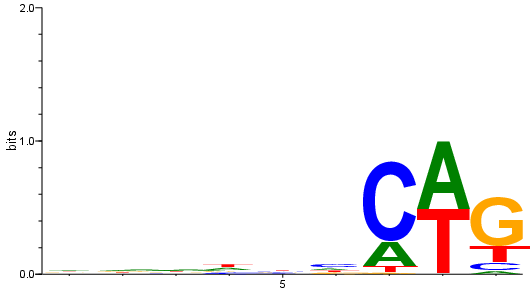

In [41]:
sl.seqlogo(sl.CompletePm(pfm = pfm.T))